Bloque 1 - Montar Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Bloque 2 - Imporatmos la libreria tensorflow

In [2]:
import tensorflow as tf

BLoque 3 - Descarga de datos

In [3]:
import kagglehub # Importa la librería kagglehub para interactuar con Kaggle y descargar datasets.

path = kagglehub.dataset_download("muhammedjunayed/wavelet-transformed-eeg-data-for-alcohol-detection")

print("Path to dataset files:", path) # Imprime la ruta donde se han descargado los archivos del dataset.

100%|██████████| 21.3M/21.3M [00:01<00:00, 14.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammedjunayed/wavelet-transformed-eeg-data-for-alcohol-detection/versions/1


Bloque 4 - Exploracion de archivos

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


path = Path(path)
img_as_jpg = list(path.rglob(r"*/*.jpg"))

# Counts the number of each categories in the dataset
file_count = list(map(lambda x: os.path.split(os.path.split(x)[0])[1],img_as_jpg))
Alc = file_count.count('Alc')
Con = file_count.count('Con')

In [5]:
Alc

468

In [6]:
Con

456

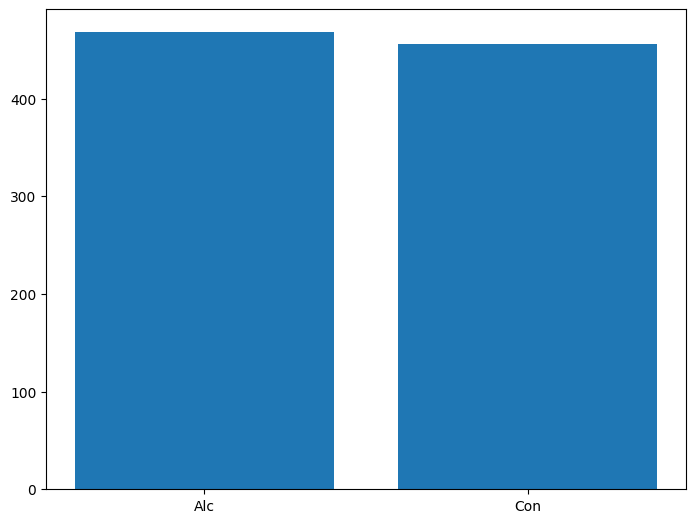

In [7]:
#VISUALIZACION DE DATA POR CLASES ALCOHOL O CONTROL
fig = plt.figure()
ax = fig.add_axes([1,1,1,1])
labels = ['Alc','Con']
count_train = [Alc, Con] # count_train should contain the count of each label
ax.bar(labels, count_train)
plt.show()

BLOQUE 5 - IMPLEMENTACION DEL MODELO PIT

In [8]:
# MODELO BotNet (Bottleneck Transformer)
# BLOQUE 01
# BotNet es una arquitectura híbrida que incorpora la autoatención (Self-Attention) en las últimas etapas
# de una red convolucional (como ResNet), permitiendo capturar dependencias globales en la imagen.

import tensorflow as tf
from tensorflow.keras import layers, models

# Clase utilitaria para acceder a claves de diccionario como atributos (obj.clave en vez de obj['clave'])
class AttrDict(dict):
    __setattr__ = dict.__setitem__
    __getattr__ = dict.__getitem__


# Función de visualización: Muestra una cuadrícula de imágenes y sus predicciones
# Verifica visualmente si el preprocesamiento (Wavelet) generó imágenes coherentes
def plot_grid_ds(ds, model=None, size=(3, 3), figsize=(10, 10)):
    from copy import copy
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import ImageGrid

    n = size[0] * size[1]
    ds_ = copy(ds)

    fig = plt.figure(figsize=figsize)
    grid = ImageGrid(
        fig,
        111,
        nrows_ncols=size,
        axes_pad=0.3,
    )
# Toma un lote del dataset, hace predicciones si hay modelo, y grafica
    for X_batch, y_batch in ds_.unbatch().shuffle(n).batch(n).take(1):
      # Proporciona un modelo, calcula la clase predicha (argmax de los logits)
        y_hat_batch = model.predict(X_batch).argmax(axis=-1) if model else y_batch
        for X, y, y_hat, ax in zip(X_batch, y_batch, y_hat_batch, grid):
            title = (
                f"{ds.class_names[y]} (true) - {ds.class_names[y_hat]} (pred)"
                if model
                else f"{ds.class_names[y]}"
            )
            ax.set_title(title)
            ax.axes.xaxis.set_visible(False)
            ax.axes.yaxis.set_visible(False)
            # Normaliza la imagen a  para mostrarla correctamente
            ax.imshow(X / 255, cmap="gray")
    return grid

# Métrica personalizada: Precisión Categórica Dispersa Balanceada
# Esencial en datasets (ej. Alcohólico) puede ser menos frecuente
# Pondera los aciertos inversamente a la frecuencia de la clase real
class BalancedSparseCategoricalAccuracy(tf.keras.metrics.SparseCategoricalAccuracy):
    def __init__(self, name="balanced_sparse_categorical_accuracy", dtype=None):
        super().__init__(name, dtype=dtype)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_flat = y_true
        if y_true.shape.ndims == y_pred.shape.ndims:
            y_flat = tf.squeeze(y_flat, axis=[-1])
        y_true_int = tf.cast(y_flat, tf.int32)

        # Calculo pesos para equilibrar la importancia de cada clase
        cls_counts = tf.math.bincount(y_true_int)
        cls_counts = tf.math.reciprocal_no_nan(tf.cast(cls_counts, self.dtype))
        weight = tf.gather(cls_counts, y_true_int)
        # Llama a la métrica original pero aplicando los pesos calculados
        return super().update_state(y_true, y_pred, sample_weight=weight)

# --- IMPLEMENTACIÓN DEL MODELO BotNet (Bottleneck Transformer) ---

class MHSA(layers.Layer):
    def __init__(self, num_heads=4, key_dim=128):
        super(MHSA, self).__init__()
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)

    def call(self, x):
        shape = tf.shape(x)
        B, H, W, C = shape[0], shape[1], shape[2], shape[3]
        x_flat = tf.reshape(x, (B, H * W, C))
        # Autoatención Multi-Cabezal (Multi-head Self Attention)
        out_flat = self.mha(x_flat, x_flat)
        # Reestructurar de vuelta a espacial (Reshape back to spatial)
        out = tf.reshape(out_flat, (B, H, W, C))
        return out

def bottleneck_block(x, filters, stride=1, use_attention=False, heads=4):
    shortcut = x
    # Proyección para el atajo (shortcut) si las dimensiones cambian
    in_filters = x.shape[-1]
    out_filters = filters * 4

    if stride != 1 or in_filters != out_filters:
        shortcut = layers.Conv2D(out_filters, kernel_size=1, strides=stride, padding="same")(x)
        shortcut = layers.BatchNormalization()(shortcut)

    # 1. Convolución 1x1
    x = layers.Conv2D(filters, kernel_size=1, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # 2. Convolución 3x3 o MHSA
    if use_attention:
        # MHSA reemplaza la convolución 3x3 en el bloque bottleneck
        # Si el stride > 1, aplicamos pooling antes de la atención.
        if stride > 1:
             x = layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2), padding="same")(x)

        # Capa de Atención
        x = MHSA(num_heads=heads, key_dim=filters // heads)(x)
        x = layers.LayerNormalization(epsilon=1e-6)(x)
    else:
        x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)

    # 3. Convolución 1x1
    x = layers.Conv2D(out_filters, kernel_size=1, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)

    # Añadir Atajo (Shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

class BotNetClassifier(tf.keras.Model):
    def __init__(self, input_shape, n_classes):
        super(BotNetClassifier, self).__init__()
        self.input_tensor_shape = input_shape
        self.n_classes = n_classes
        self._construct_model()

    def call(self, x):
        return self._model(x)

    def _construct_model(self):
        inputs = layers.Input(shape=self.input_tensor_shape)

        # Tallo (Stem estándar de ResNet)
        x = layers.Conv2D(64, 7, strides=2, padding="same")(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Etapa 1
        x = bottleneck_block(x, 64, stride=1)
        x = bottleneck_block(x, 64, stride=1)

        # Etapa 2
        x = bottleneck_block(x, 128, stride=2)
        x = bottleneck_block(x, 128, stride=1)

        # Etapa 3
        x = bottleneck_block(x, 256, stride=2)
        x = bottleneck_block(x, 256, stride=1)

        # Etapa 4 (Etapa BotNet - usa Atención)
        x = bottleneck_block(x, 512, stride=2, use_attention=True)
        x = bottleneck_block(x, 512, stride=1, use_attention=True)

        # Cabezal (Head)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.5)(x)
        outputs = layers.Dense(self.n_classes)(x)

        self._model = models.Model(inputs=inputs, outputs=outputs, name="BotNet_Internal")



In [9]:
#08
train = pd.concat([pd.Series(img_as_jpg,name="image").apply(str),pd.Series(file_count, name="type")],axis=1)
train = train.sample(frac=1).reset_index(drop=True)
print(np.shape(train))

(924, 2)


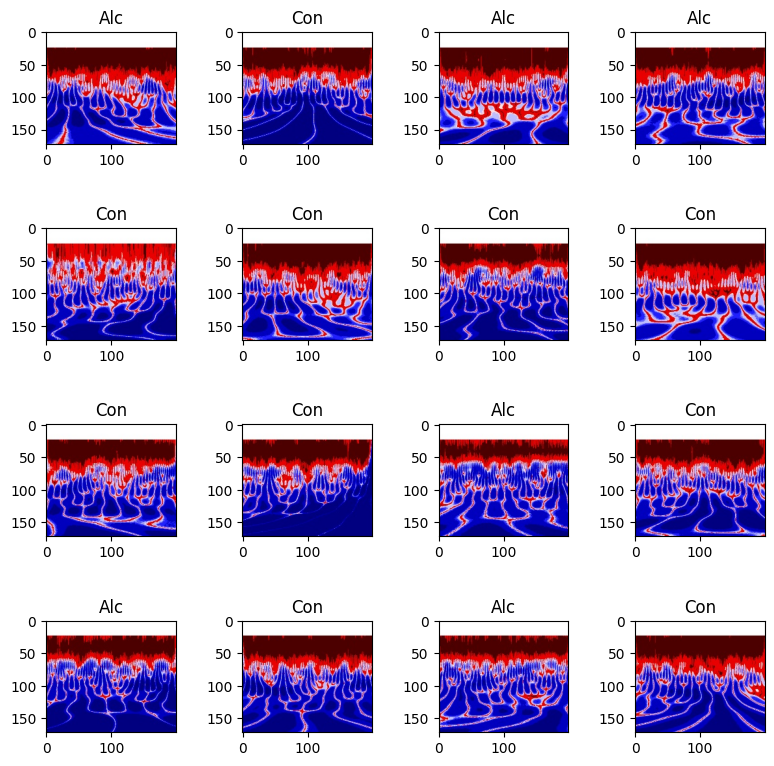

In [10]:
#09
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.tight_layout()
counter = 0
for ax in axes.reshape(-1):
    ax.imshow(plt.imread(train["image"][counter]))
    ax.set_title(train["type"][counter])
    plt.rcParams["axes.grid"] = False
    counter = counter+1

In [17]:
hparams = AttrDict(
    image_size=(224, 224, 3),  # Adjusted to be divisible by patch size
    n_classes=2,
    batch_size=32,
)

ds = tf.keras.preprocessing.image_dataset_from_directory("/content/drive/MyDrive/Papper_Titulo /EEG", image_size=hparams.image_size[:-1], batch_size=hparams.batch_size)
train_split = round(0.8 * ds.cardinality().numpy())
train_ds = ds.take(train_split); train_ds.class_names = ds.class_names
validation_ds = ds.skip(train_split); validation_ds.class_names = ds.class_names

Found 924 files belonging to 2 classes.


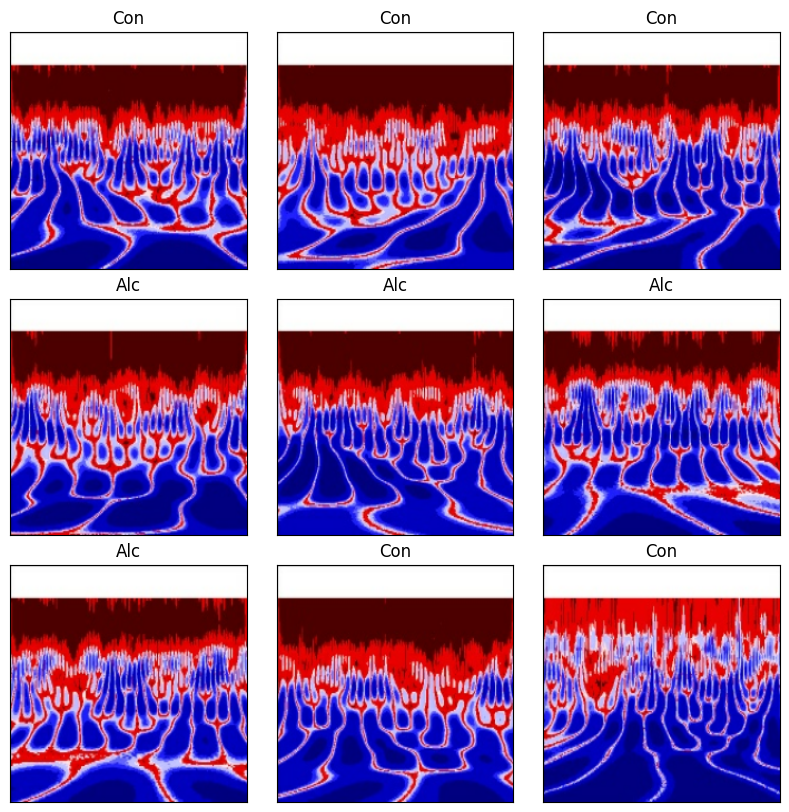

In [18]:
_ = plot_grid_ds(train_ds)


BLOQUE 5: RESULTADOS DEL MODELO PIT

---



Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 424ms/step - accuracy: 0.5099 - balanced_sparse_categorical_accuracy: 0.5000 - loss: 40.9571 - val_accuracy: 0.4840 - val_balanced_sparse_categorical_accuracy: 0.5000 - val_loss: 0.7847
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 372ms/step - accuracy: 0.4912 - balanced_sparse_categorical_accuracy: 0.4991 - loss: 0.7620 - val_accuracy: 0.5479 - val_balanced_sparse_categorical_accuracy: 0.5000 - val_loss: 0.7042
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 381ms/step - accuracy: 0.4964 - balanced_sparse_categorical_accuracy: 0.5000 - loss: 0.7281 - val_accuracy: 0.5532 - val_balanced_sparse_categorical_accuracy: 0.5000 - val_loss: 0.6875
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 377ms/step - accuracy: 0.5142 - balanced_sparse_categorical_accuracy: 0.5021 - loss: 0.7212 - val_accuracy: 0.4947 - val_balanced_sparse_categorical_accuracy: 0.5000 - val_loss: 0.7430
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 374ms/step - accuracy: 0.5349 - balanced_sparse_categ

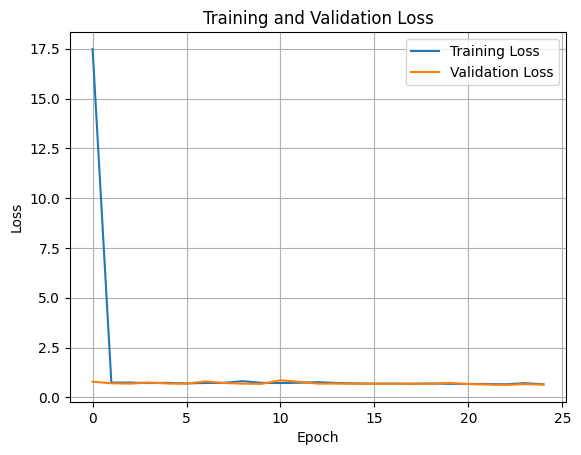

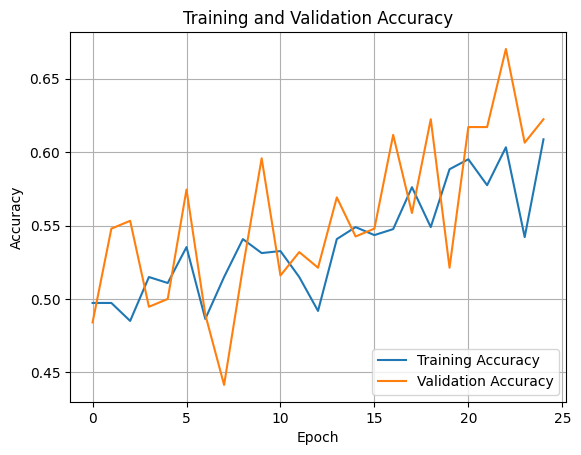

Final Training Accuracy: 60.87%
Final Validation Accuracy: 62.23%
Total time taken: 223.93 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 370ms/step


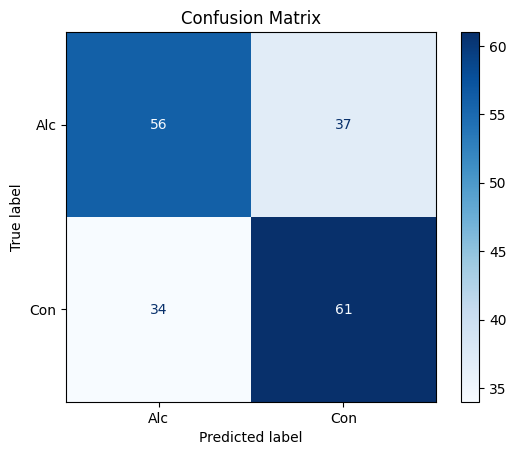


Class-wise Precision: [0.62222222 0.62244898]

Class-wise Recall: [0.60215054 0.64210526]

Class-wise F1-score: [0.61202186 0.63212435]

Overall Accuracy: 62.23%

Macro Precision: 0.6223356009070296

Macro Recall: 0.6221279003961517

Macro F1-score: 0.6220731051275518


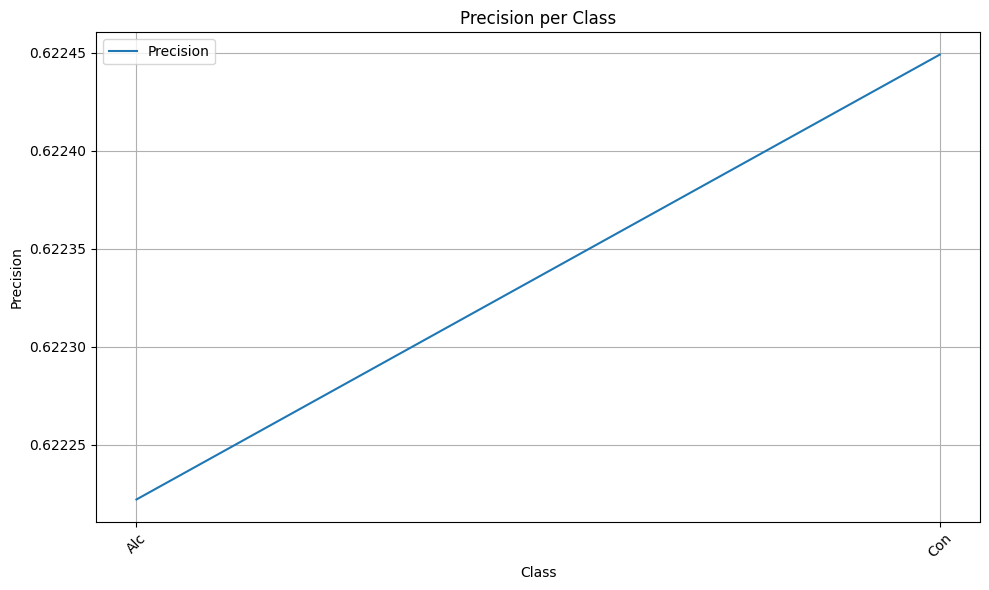

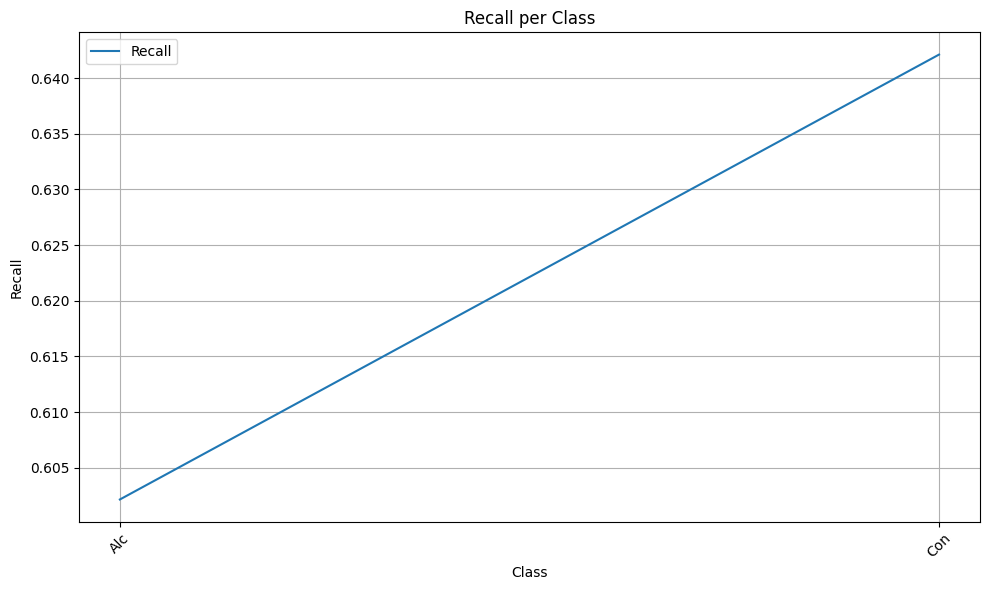

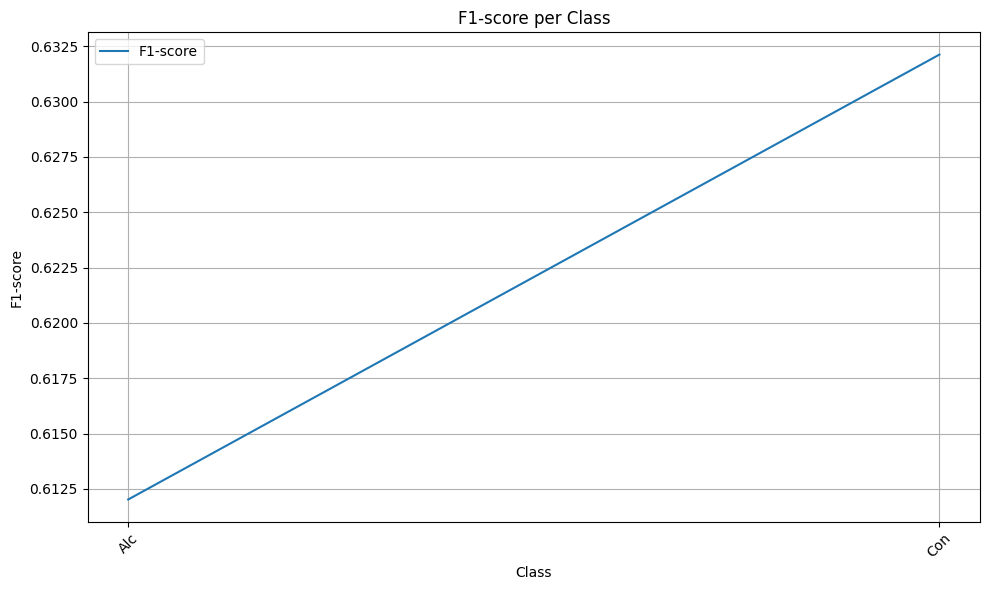

In [19]:
import time
import tensorflow as tf
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- CORRECCIÓN: Re-instanciar el modelo para asegurar que se use la definición de clase actualizada ---
# Verificar si existe la estrategia, de lo contrario crearla
if 'strategy' not in globals():
    strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    # Convertir hparams a un diccionario regular para compatibilidad si es necesario, o acceder directamente
    # Asumiendo que hparams está disponible desde celdas anteriores
    input_shape = hparams['image_size']
    n_classes = hparams['n_classes']

    # Reconstruir el modelo con la clase BotNetClassifier CORRECTA
    model = BotNetClassifier(input_shape, n_classes)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy", BalancedSparseCategoricalAccuracy()]
    )
# --------------------------------------------------------------------------------

start = time.time()

# Configurar un callback para registrar pérdida y precisión durante el entrenamiento
class TrainingHistory(tf.keras.callbacks.Callback):
  def __init__(self):
    self.losses = []
    self.val_losses = []
    self.accuracies = []
    self.val_accuracies = []

  def on_epoch_end(self, epoch, logs=None):
    self.losses.append(logs.get('loss'))
    self.val_losses.append(logs.get('val_loss'))
    self.accuracies.append(logs.get('accuracy'))
    self.val_accuracies.append(logs.get('val_accuracy'))

# Entrenar el modelo con el callback configurado
history_pit = TrainingHistory()
model.fit(train_ds, epochs=25, validation_data=validation_ds, callbacks=[history_pit])

# Graficar las curvas de pérdida de entrenamiento y validación
plt.plot(history_pit.losses, label='Training Loss')
plt.plot(history_pit.val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Graficar las curvas de precisión de entrenamiento y validación
plt.plot(history_pit.accuracies, label='Training Accuracy')
plt.plot(history_pit.val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Imprimir la precisión general final
final_accuracy = history_pit.accuracies[-1]
final_val_accuracy = history_pit.val_accuracies[-1]
print(f"Final Training Accuracy: {final_accuracy * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_accuracy * 100:.2f}%")

end = time.time()
print(f"Total time taken: {end - start:.2f} seconds")

## Matriz de Confusión y Cálculo de Métricas

# Asumiendo que ya has entrenado el modelo y tienes el dataset de validación (validation_ds)

# Obtener etiquetas verdaderas y predicciones
X_val, y_true = [], []
for images, labels in validation_ds:
    X_val.extend(images.numpy())
    y_true.extend(labels.numpy())
X_val = np.array(X_val)
y_true = np.array(y_true)

# Realizar predicciones
y_pred = model.predict(X_val).argmax(axis=1)

# Función para graficar la matriz de confusión
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues")
    plt.title('Confusion Matrix')
    plt.show()

# Graficar la matriz de confusión
plot_confusion_matrix(y_true, y_pred, class_names=validation_ds.class_names)

# Calcular e imprimir métricas de clasificación
class_wise_precision = precision_score(y_true, y_pred, average=None)
class_wise_recall = recall_score(y_true, y_pred, average=None)
class_wise_f1 = f1_score(y_true, y_pred, average=None)

print("\nClass-wise Precision:", class_wise_precision)
print("\nClass-wise Recall:", class_wise_recall)
print("\nClass-wise F1-score:", class_wise_f1)

# Puntajes Generales
accuracy = np.mean(y_true == y_pred)
macro_precision = precision_score(y_true, y_pred, average='macro')
macro_recall = recall_score(y_true, y_pred, average='macro')
macro_f1 = f1_score(y_true, y_pred, average='macro')

# Imprimir precisión general en porcentaje
print(f"\nOverall Accuracy: {accuracy * 100:.2f}%")
print("\nMacro Precision:", macro_precision)
print("\nMacro Recall:", macro_recall)
print("\nMacro F1-score:", macro_f1)

# Graficar precisión, recuperación y puntaje F1 para cada clase
plt.figure(figsize=(10, 6))
plt.plot(class_wise_precision, label='Precision')
plt.xticks(range(len(class_wise_precision)), validation_ds.class_names, rotation=45)
plt.xlabel('Class')
plt.ylabel('Precision')
plt.title('Precision per Class')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(class_wise_recall, label='Recall')
plt.xticks(range(len(class_wise_recall)), validation_ds.class_names, rotation=45)
plt.xlabel('Class')
plt.ylabel('Recall')
plt.title('Recall per Class')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(class_wise_f1, label='F1-score')
plt.xticks(range(len(class_wise_f1)), validation_ds.class_names, rotation=45)
plt.xlabel('Class')
plt.ylabel('F1-score')
plt.title('F1-score per Class')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


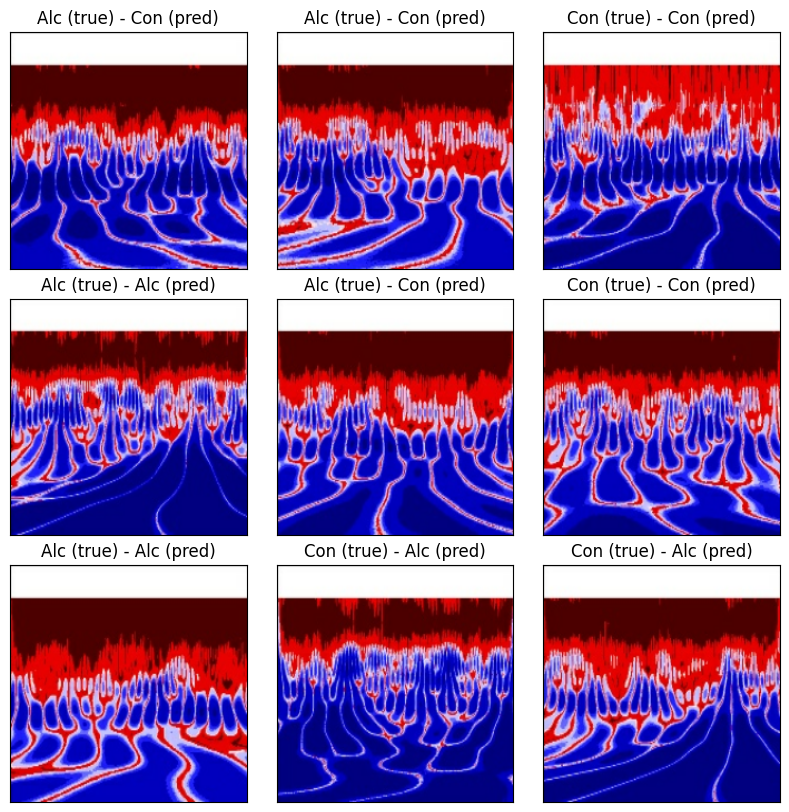

In [20]:
_ = plot_grid_ds(validation_ds,  model=model)

In [21]:
print("\nMacro F1-score:", macro_f1)



Macro F1-score: 0.6220731051275518


In [22]:
import pandas as pd

# === Datos del modelo (ajusta el nombre si quieres) ===
MODEL_NAME = "BotNet"
EPOCHS = 25
BATCH_SIZE = hparams.batch_size

# Obtener LR y optimizador desde el propio modelo
learning_rate = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
optimizer_name = type(model.optimizer).__name__

# Crear DataFrame con una fila de resultados
df_resultados = pd.DataFrame([{
    "Model": MODEL_NAME,
    "Accuracy": round(accuracy, 4),
    "Precision": round(macro_precision, 4),
    "Recall": round(macro_recall, 4),
    "F1-Score": round(macro_f1, 4),
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,

}])

# Mostrar tabla bonita en el notebook
df_resultados

,Model,Accuracy,Precision,Recall,F1-Score,batch_size,epochs
0,BotNet,0.6223,0.6223,0.6221,0.6221,32,25


In [23]:
# Parche para corregir el conflicto de 'AttrDict' con la inspección de variables de Colab
# Esto evita el KeyError: 'shape' al cambiarlo por el AttributeError esperado
try:
    if 'AttrDict' in globals():
        def getattr_patch(self, key):
            try:
                return self[key]
            except KeyError:
                raise AttributeError(f"'AttrDict' object has no attribute '{key}'")
        AttrDict.__getattr__ = getattr_patch
except Exception:
    pass

# Definir la ruta donde se guardará el modelo
# Se utiliza la extensión .keras que es el formato recomendado actualmente
save_path = '/content/drive/MyDrive/Papper_Titulo /04_BotNet_EEG_Alcohol_Detection.keras'

# Guardar el modelo
model.save(save_path)

print(f"Modelo guardado exitosamente en: {save_path}")

Modelo guardado exitosamente en: /content/drive/MyDrive/Papper_Titulo /04_BotNet_EEG_Alcohol_Detection.keras


In [ ]:
# Tabla por clase
df_por_clase = pd.DataFrame({
    "Class": validation_ds.class_names,
    "Precision": class_wise_precision,
    "Recall": class_wise_recall,
    "F1-Score": class_wise_f1,
})

df_por_clase

,Class,Precision,Recall,F1-Score
0,Alc,0.733333,0.159420,0.261905
1,Con,0.588652,0.954023,0.728070
